<a href="https://colab.research.google.com/github/arumugam-ai2026/GenAI-L3-Assignement/blob/main/L3_Assignment_4_3DPlotting_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D



In [10]:
# House Price Dataset
data = {
    'Area': [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800],
    'Bedrooms': [2, 2, 3, 3, 4, 4, 5, 5],
    'Price': [200000, 240000, 300000, 340000, 400000, 450000, 500000, 560000]
}

df = pd.DataFrame(data)



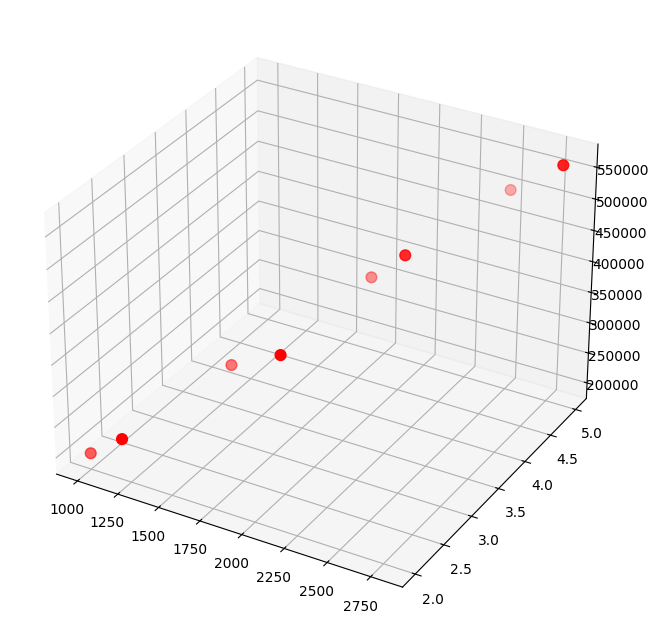

In [11]:
# Features and Target
X = df[['Area', 'Bedrooms']]
y = df['Price']

# Train Linear Regression Model
model = LinearRegression()
model.fit(X, y)

# Create 3D Figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot actual data points
ax.scatter(
    df['Area'],
    df['Bedrooms'],
    df['Price'],
    color='red',
    s=60,
    label='Actual Data'
)

# Create mesh grid
area_range = np.linspace(df['Area'].min(), df['Area'].max(), 20)
bedroom_range = np.linspace(df['Bedrooms'].min(), df['Bedrooms'].max(), 20)

area_grid, bedroom_grid = np.meshgrid(
    area_range,
    bedroom_range
)

# Create DataFrame with feature names
grid_df = pd.DataFrame({
    'Area': area_grid.ravel(),
    'Bedrooms': bedroom_grid.ravel()
})

# Predict prices
predicted_price = model.predict(grid_df)

# Reshape predictions
price_grid = predicted_price.reshape(area_grid.shape)



In [12]:
# Plot regression plane
ax.plot_surface(
    area_grid,
    bedroom_grid,
    price_grid,
    alpha=0.5,
    color='cyan'
)

# Labels
ax.set_xlabel('Area (sq.ft)')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('Price ($)')
ax.set_title('3D House Price Prediction Model')

plt.show()